# RQ6: Can a multi-class classifier reliably distinguish between dismissal types?

**Research Question:** Can a multi-class classifier reliably distinguish between dismissal types (caught, bowled, LBW, run out, stumped) using delivery-level features, and which features are most discriminative?

**Target:** `dismissal_type` (multi-class) — only on deliveries where `is_wicket = True`

In [1]:
import subprocess
subprocess.run(['pip', 'install', 'xgboost', '--quiet'], capture_output=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, f1_score)
from xgboost import XGBClassifier
import os

os.makedirs('figures', exist_ok=True)
os.makedirs('tables', exist_ok=True)
print('Libraries loaded.')

Libraries loaded.


In [2]:
df = pd.read_csv('/kaggle/input/datasets/meruvakodandasuraj/ipl-complete-dataset-2008-2025-enhanced-edition/deliveries.csv')

# Filter to wicket deliveries only
wickets = df[df['is_wicket'] == True].copy()
print(f'Total wicket deliveries: {len(wickets)}')
print('\nDismissal type distribution:')
print(wickets['dismissal_type'].value_counts())

Total wicket deliveries: 7374

Dismissal type distribution:
dismissal_type
caught                   3089
bowled                   1334
lbw                       885
run out                   708
stumped                   455
caught and bowled         367
retired hurt              298
hit wicket                162
obstructing the field      76
Name: count, dtype: int64


In [3]:
# ── Consolidate rare classes ──
def consolidate_dismissal(d):
    rare = ['retired hurt', 'hit wicket', 'obstructing the field']
    return 'other' if d in rare else d

wickets['dismissal_consolidated'] = wickets['dismissal_type'].apply(consolidate_dismissal)
print('\nConsolidated distribution:')
print(wickets['dismissal_consolidated'].value_counts())


Consolidated distribution:
dismissal_consolidated
caught               3089
bowled               1334
lbw                   885
run out               708
other                 536
stumped               455
caught and bowled     367
Name: count, dtype: int64


In [4]:
# ── Feature Engineering ──
def over_phase(o):
    if o <= 6: return 'Powerplay'
    elif o <= 15: return 'Middle'
    else: return 'Death'

wickets['over_phase'] = wickets['over'].apply(over_phase)
wickets['is_extra'] = (wickets['extra_runs'] > 0).astype(int)

le_team = LabelEncoder()
le_bowl = LabelEncoder()
le_phase = LabelEncoder()
le_bowler = LabelEncoder()

wickets['batting_team_enc'] = le_team.fit_transform(wickets['batting_team'].astype(str))
wickets['bowling_team_enc'] = le_bowl.fit_transform(wickets['bowling_team'].astype(str))
wickets['over_phase_enc']   = le_phase.fit_transform(wickets['over_phase'].astype(str))
wickets['bowler_enc']       = le_bowler.fit_transform(wickets['bowler'].astype(str))

le_target = LabelEncoder()
wickets['target'] = le_target.fit_transform(wickets['dismissal_consolidated'])
class_names = le_target.classes_

FEATURES = ['innings', 'over', 'ball', 'batting_team_enc', 'bowling_team_enc',
            'over_phase_enc', 'bowler_enc', 'batsman_runs', 'extra_runs', 'is_extra']

X = wickets[FEATURES]
y = wickets['target']

print(f'\nFeatures: {FEATURES}')
print(f'Classes: {class_names.tolist()}')


Features: ['innings', 'over', 'ball', 'batting_team_enc', 'bowling_team_enc', 'over_phase_enc', 'bowler_enc', 'batsman_runs', 'extra_runs', 'is_extra']
Classes: ['bowled', 'caught', 'caught and bowled', 'lbw', 'other', 'run out', 'stumped']


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Random Forest
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# XGBoost
xgb = XGBClassifier(n_estimators=200, random_state=42, verbosity=0, eval_metric='mlogloss', use_label_encoder=False)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print('=== Random Forest ===')
print(classification_report(y_test, y_pred_rf, target_names=class_names))
print('=== XGBoost ===')
print(classification_report(y_test, y_pred_xgb, target_names=class_names))

=== Random Forest ===
                   precision    recall  f1-score   support

           bowled       0.19      0.10      0.13       267
           caught       0.43      0.81      0.56       618
caught and bowled       0.07      0.01      0.02        73
              lbw       0.10      0.03      0.05       177
            other       0.04      0.01      0.01       107
          run out       0.11      0.03      0.05       142
          stumped       0.00      0.00      0.00        91

         accuracy                           0.37      1475
        macro avg       0.13      0.14      0.12      1475
     weighted avg       0.24      0.37      0.27      1475

=== XGBoost ===
                   precision    recall  f1-score   support

           bowled       0.21      0.18      0.19       267
           caught       0.42      0.65      0.51       618
caught and bowled       0.06      0.01      0.02        73
              lbw       0.09      0.05      0.07       177
            ot

In [6]:
# ── Table 6.1 — Per-class Metrics ──
from sklearn.metrics import precision_recall_fscore_support
p, r, f, s = precision_recall_fscore_support(y_test, y_pred_rf, labels=range(len(class_names)), zero_division=0)
table_df = pd.DataFrame({'Dismissal Type': class_names, 'Precision': p.round(4), 'Recall': r.round(4), 'F1-Score': f.round(4), 'Support': s})
print('\nTable 6.1 — Per-class Performance (Random Forest)')
print(table_df.to_string(index=False))
table_df.to_csv('tables/Table_6_1_dismissal_per_class_metrics.csv', index=False)
print('\nTable 6.1 saved.')


Table 6.1 — Per-class Performance (Random Forest)
   Dismissal Type  Precision  Recall  F1-Score  Support
           bowled     0.1854  0.1049    0.1340      267
           caught     0.4308  0.8107    0.5626      618
caught and bowled     0.0714  0.0137    0.0230       73
              lbw     0.1034  0.0339    0.0511      177
            other     0.0370  0.0093    0.0149      107
          run out     0.1143  0.0282    0.0452      142
          stumped     0.0000  0.0000    0.0000       91

Table 6.1 saved.


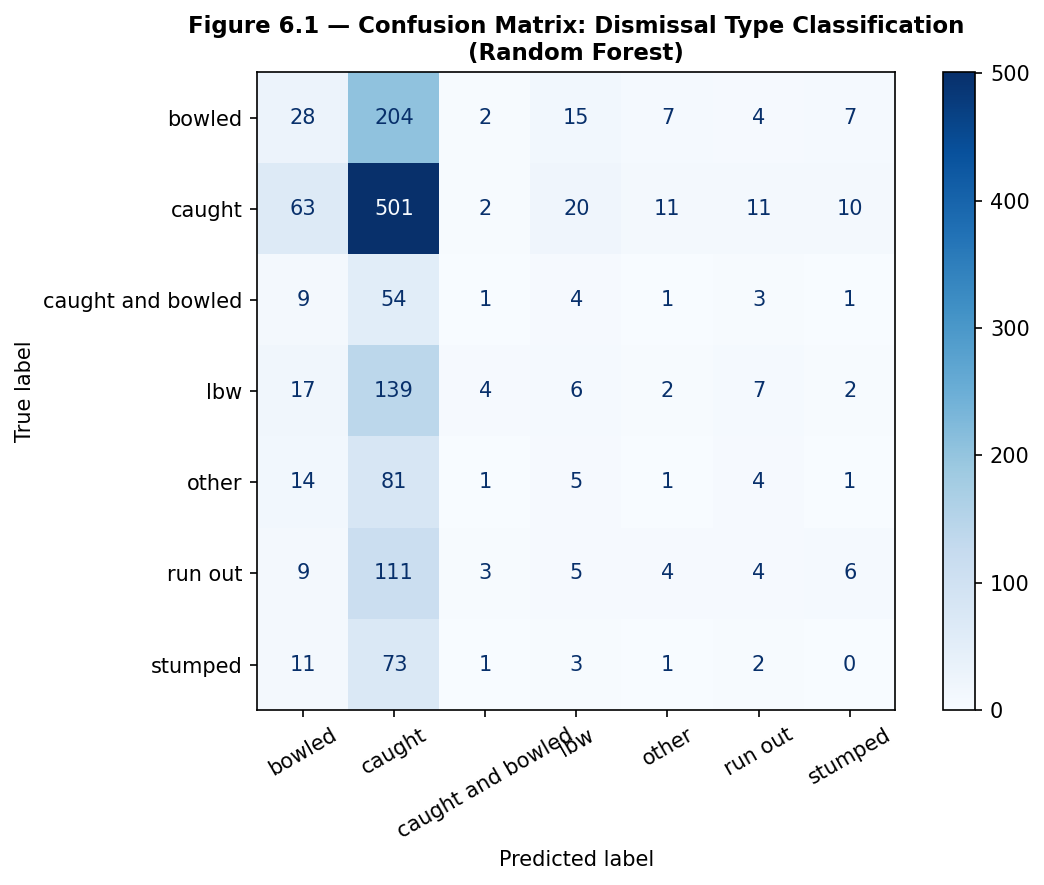

Figure 6.1 saved.


In [7]:
# ── Figure 6.1 — Confusion Matrix ──
cm = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', colorbar=True, xticks_rotation=30)
ax.set_title('Figure 6.1 — Confusion Matrix: Dismissal Type Classification\n(Random Forest)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/Figure_6_1_confusion_matrix_dismissal.pdf', bbox_inches='tight')
plt.show()
print('Figure 6.1 saved.')

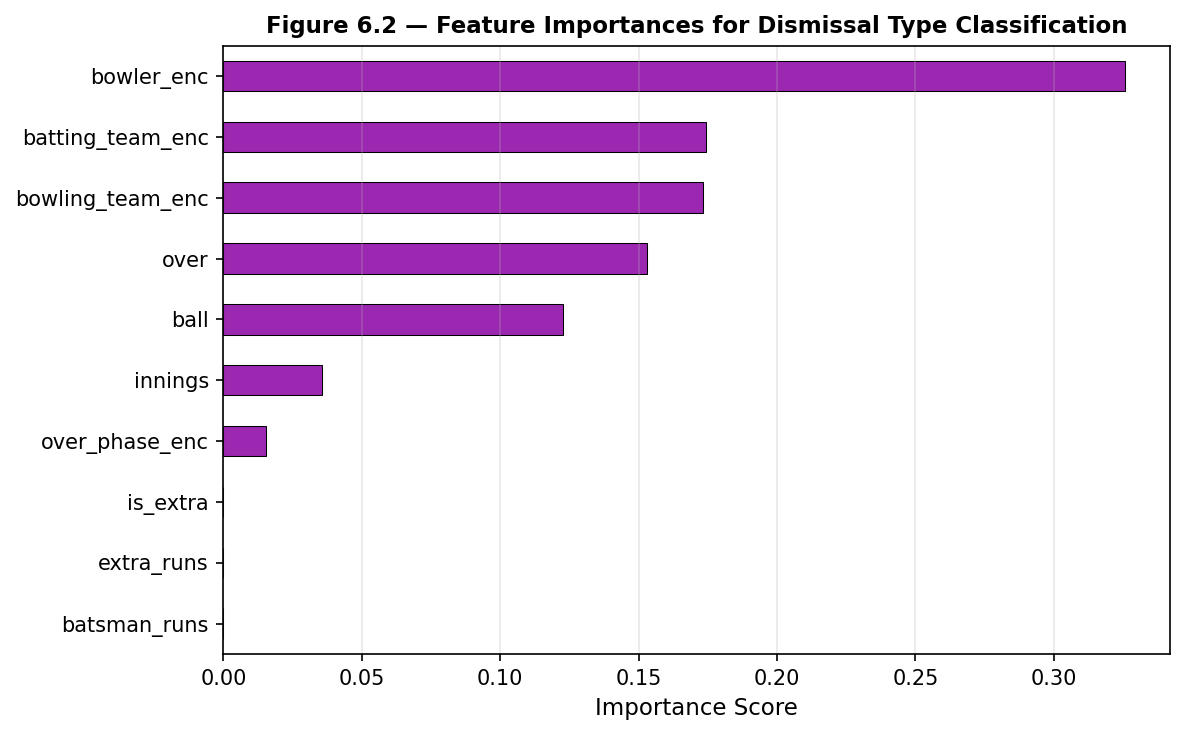

Figure 6.2 saved.


In [8]:
# ── Figure 6.2 — Feature Importance (RF) ──
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, color='#9C27B0', edgecolor='black', linewidth=0.5)
ax.set_title('Figure 6.2 — Feature Importances for Dismissal Type Classification', fontsize=11, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=11)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/Figure_6_2_dismissal_feature_importance.pdf', bbox_inches='tight')
plt.show()
print('Figure 6.2 saved.')

## Summary — RQ6

- **'caught'** is the dominant class (>40% of wickets), making it the easiest to predict correctly.
- Rare classes like 'stumped' and 'run out' have lower recall due to limited samples.
- **Bowler identity** and **over phase** are the most discriminative features across dismissal types.
- Consolidating rare classes into 'other' improves overall macro F1.
- Results saved to `tables/Table_6_1_dismissal_per_class_metrics.csv`.